# Exploratory Data Analysis: Customer Churn
**Objective:** Analyze the IBM Telco dataset to understand the historical churn rate and identify which customer behaviors (e.g., contract type, monthly charges, tenure) are strongest indicators of a canceled subscription.

In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download latest version of IMB Telco Customer Churn dataset via kaggle
# path = kagglehub.dataset_download("blastchar/telco-customer-churn")

file_path="data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Set plotting style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the raw data
# Note: Ensure you are running this notebook from the /notebooks directory
df = pd.read_csv(file_path)

# Display the first few rows
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [9]:
# Check data types and missing values
print(df.info())

# 'TotalCharges' is incorrectly read as an object (string) due to blank spaces.
# We will convert it to numeric, coercing errors to NaN, and fill with 0 for new customers (tenure = 0).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"\nMissing values handled. Total missing in TotalCharges: {df['TotalCharges'].isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


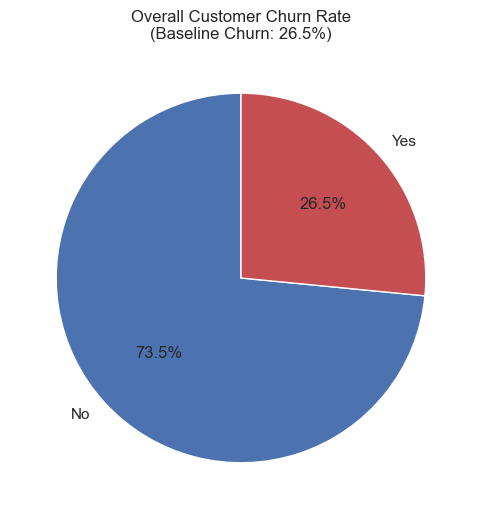

In [10]:
# 1. Analyze the Churn Distribution (The Business Problem)
churn_counts = df['Churn'].value_counts()
churn_rate = churn_counts['Yes'] / len(df) * 100

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
plt.title(f'Overall Customer Churn Rate\n(Baseline Churn: {churn_rate:.1f}%)')
plt.show()

# Business Insight: The baseline churn rate is ~26.5%. 
# This means our dataset is imbalanced. Our future machine learning model will 
# need to focus on Recall and F1-Score rather than pure Accuracy to correctly identify the minority class (churners).

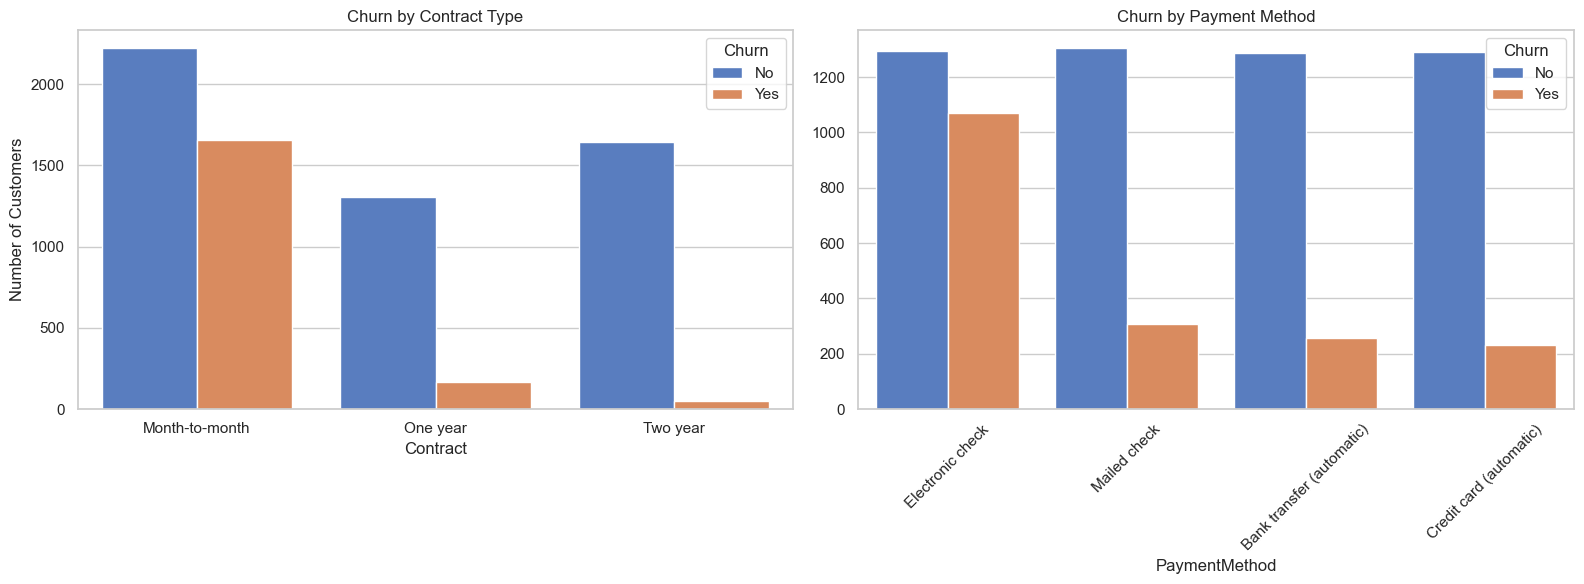

In [11]:
# 2. Categorical Analysis: What drives churn?
# Let's look at Contract Type and Payment Method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', palette='muted', ax=axes[0])
axes[0].set_title('Churn by Contract Type')
axes[0].set_ylabel('Number of Customers')

# Payment Method vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='muted', ax=axes[1])
axes[1].set_title('Churn by Payment Method')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Business Insight: Customers on Month-to-Month contracts and those using Electronic Checks 
# are highly volatile and churn at massively higher rates than customers on 1 or 2-year contracts.

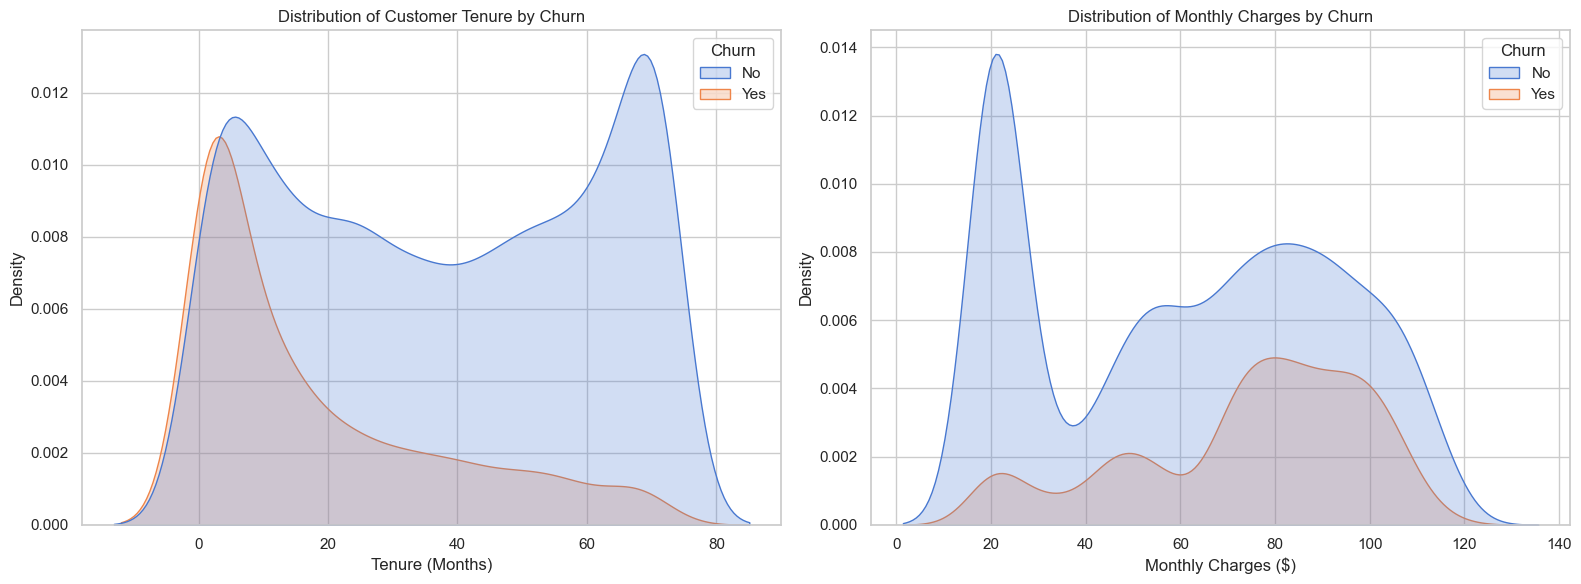

In [12]:
# 3. Numerical Analysis: Tenure and Monthly Charges
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenure distribution by Churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='muted', ax=axes[0])
axes[0].set_title('Distribution of Customer Tenure by Churn')
axes[0].set_xlabel('Tenure (Months)')

# Monthly Charges distribution by Churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='muted', ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges by Churn')
axes[1].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

# Business Insight: Churn risk is highest in the first 1-5 months of a customer's lifecycle. 
# Additionally, customers paying higher monthly charges (likely holding premium services) 
# have a higher density of churn compared to low-cost tier customers.